In [2]:
pip install pandas matplotlib sqlite3

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 16.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [10]:
import mysql.connector
print(mysql.connector.__version__)

9.3.0


In [2]:
import mysql.connector

# Connect to MySQL
cnx = mysql.connector.connect(
    host="localhost",
    user="root",
    password="password",
    database="Financial_db"
)
print("Connected successfully!")
cnx.close()

Connected successfully!


In [6]:
import pandas as pd
import mysql.connector
from mysql.connector import Error

# Read CSV
df = pd.read_excel('Superstore.xlsx')

# Connect to MySQL
try:
    cnx = mysql.connector.connect(
        host="localhost",
        user="root",
        password="password",
        database="Financial_db"
    )
    cursor = cnx.cursor()

    # Insert data
    for _, row in df.iterrows():
        sql = """
        INSERT INTO superstore (
            Row_ID, Order_ID, Order_Date, Ship_Date, Ship_Mode, Customer_ID,
            Customer_Name, Segment, Country, City, State, Postal_Code, Region,
            Product_ID, Category, Sub_Category, Product_Name, Sales, Quantity,
            Discount, Profit
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """
        values = (
            row['Row ID'], row['Order ID'], row['Order Date'], row['Ship Date'],
            row['Ship Mode'], row['Customer ID'], row['Customer Name'], row['Segment'],
            row['Country'], row['City'], row['State'], row['Postal Code'], row['Region'],
            row['Product ID'], row['Category'], row['Sub-Category'], row['Product Name'],
            row['Sales'], row['Quantity'], row['Discount'], row['Profit']
        )
        cursor.execute(sql, values)

    cnx.commit()
    print("Data imported successfully!")

except Error as e:
    print(f"Error: {e}")

finally:
    cursor.close()
    cnx.close()

Data imported successfully!


In [10]:
import pandas as pd

df = pd.read_excel("Superstore.xlsx")

print(df.head())
print(df.describe())
print(df.info())
print(df.isnull().sum())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [19]:
import pandas as pd 

# Load the top_products_csv
top_products = pd.read_csv("top_products.csv")

# Clean Data
top_products["Total_Sales"] = top_products["Total_Sales"].round(2) # round to 2 decimal place
top_products["Product_Name"] = top_products["Product_Name"].str.strip() # Remove whitespace
top_products.dropna(subset=["Total_Sales", "Total_Quantity"], inplace=True) # Remove nulls

# Save Cleaned Data
top_products.to_csv("top_products_cleaned.csv", index=False)
top_products.to_excel("top_products_cleaned.xlsx", index=False)

# Inspect Cleaned Data
print(top_products.head()) # print top 5 rows
print(top_products.isnull().sum()) # Count null occurence

                                        Product_Name         Category  \
0              Canon imageCLASS 2200 Advanced Copier       Technology   
1  Fellowes PB500 Electric Punch Plastic Comb Bin...  Office Supplies   
2  Cisco TelePresence System EX90 Videoconferenci...       Technology   
3       HON 5400 Series Task Chairs for Big and Tall        Furniture   
4         GBC DocuBind TL300 Electric Binding System  Office Supplies   

   Total_Sales  Total_Quantity  
0     61599.82              20  
1     27453.38              31  
2     22638.48               6  
3     21870.58              39  
4     19823.48              37  
Product_Name      0
Category          0
Total_Sales       0
Total_Quantity    0
dtype: int64


In [23]:
import pandas as pd
import mysql.connector

cnx = mysql.connector.connect(
    host="localhost",
    user="root",
    password="password",
    database="Financial_db"
)

# Export sales by region
sales_by_region = pd.read_sql("SELECT * FROM sales_by_region_cleaned", cnx)
sales_by_region.to_excel("sales_by_region_cleaned.xlsx", index=False)

# Export monthly trends
monthly_trends = pd.read_sql("SELECT * FROM monthly_trends_cleaned", cnx)
monthly_trends.to_excel("monthly_trends_cleaned.xlsx", index=False)

cnx.close()
print("Data exported to Excel!!!")

Data exported to Excel!!!


/var/folders/54/rwgtd99n1xgbl75n5l276w7w0000gn/T/ipykernel_57583/1528778519.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_by_region = pd.read_sql("SELECT * FROM sales_by_region_cleaned", cnx)
/var/folders/54/rwgtd99n1xgbl75n5l276w7w0000gn/T/ipykernel_57583/1528778519.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_trends = pd.read_sql("SELECT * FROM monthly_trends_cleaned", cnx)


In [ ]:
import pandas as pd
import numpy as np

# Load CSVs
regional_performance = pd.read_csv("regional_performance.csv")
negative_profit = pd.read_csv("negative_profit.csv")
monthly_profit = pd.read_csv("monthly_profit.csv")

# Summary Statistics: Regional Performance
print("Regional Perfomance Stats:")
print(regional_performance.describe())
print("\nProfit Margin Distribution:")
print(regional_performance['Profit_Margin'].quantile([0.25, 0.5, 0.75]))

# Identify Outliers: Regions with unusually low profit margins

low_margin_threshold = regional_performance["Profit_Margin"].quantile(0.25)
low_margin_regions = regional_performance[regional_performance['Profit_Margin'] < low_margin_threshold]
print("\nRegions with Low Profit Margins:")
print(low_margin_regions[["Region", 'Profit_Margin']])

# high_margin_threshold = regional_performance["Profit_Margin"].quantile(0.75)
# high_margin_regions = regional_performance[regional_performance['Profit_Margin'] > high_margin_threshold]
# print("\nRegions with High Profit Margin")
# print(high_margin_regions[["Region", "Profit_Margin"]])

# Summary Statistics: Monthly Profit
print("\nMonthly Profit Stats:")
print(monthly_profit.describe())
print("\nMonths with Negative Profit:")
print(monthly_profit[monthly_profit['Total_Profit'] < 0][['Order_Month', "Total_Profit"]])

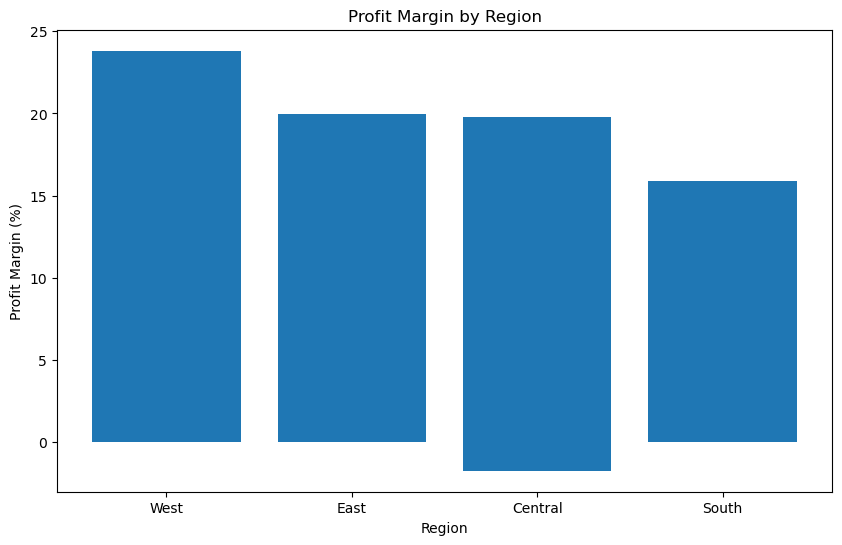

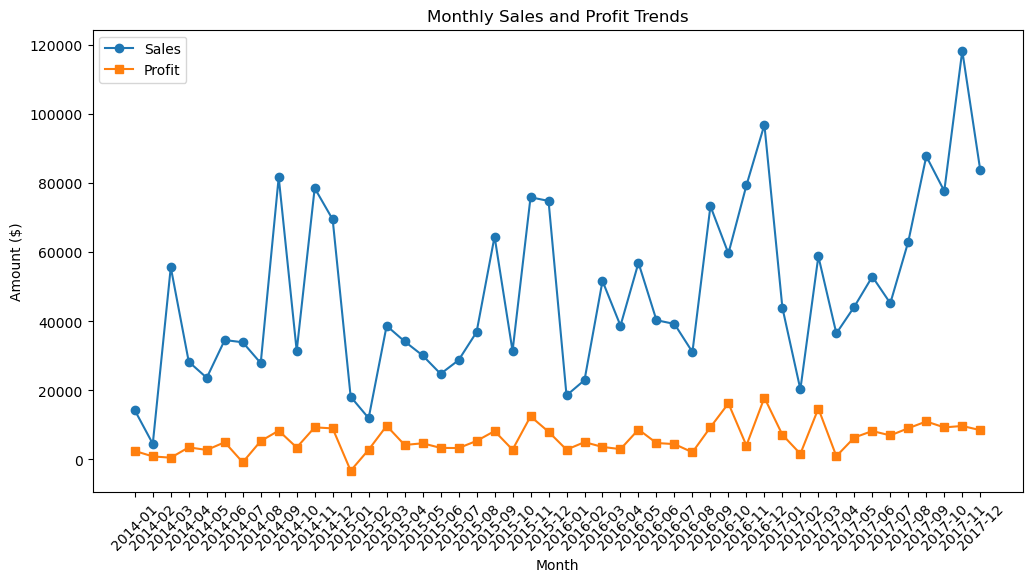

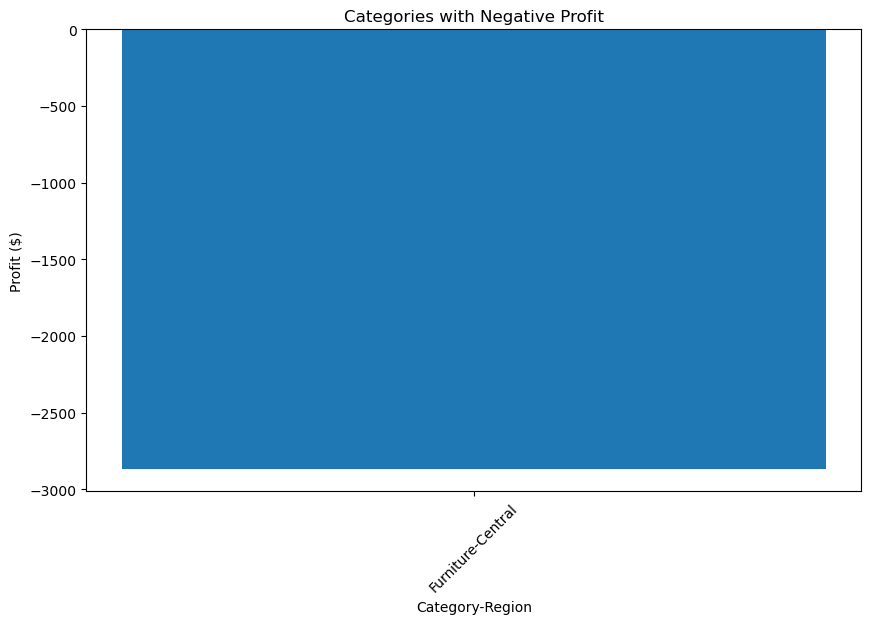

In [81]:
import matplotlib.pyplot as plt
%matplotlib inline

# Plot 1: Profit Margin by Region
plt.figure(figsize=(10, 6))
plt.bar(regional_performance['Region'], regional_performance['Profit_Margin'])
plt.title('Profit Margin by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin (%)')
plt.savefig('profit_margin_by_region.png')
plt.show()

# Plot 2: Monthly Sales and Profit Trends
plt.figure(figsize=(12, 6))
plt.plot(monthly_profit['Order_Month'], monthly_profit['Total_Sales'], label='Sales', marker='o')
plt.plot(monthly_profit['Order_Month'], monthly_profit['Total_Profit'], label='Profit', marker='s')
plt.title('Monthly Sales and Profit Trends')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend()
plt.xticks(rotation=45)
plt.savefig('monthly_sales_profit.png')
plt.show()

# Plot 3: Negative Profit Categories
plt.figure(figsize=(10, 6))
plt.bar(negative_profit['Category'] + '-' + negative_profit['Region'], negative_profit['Total_Profit'])
plt.title('Categories with Negative Profit')
plt.xlabel('Category-Region')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45)
plt.savefig('negative_profit_categories.png')
plt.show()